# TCGA Pan-Cancer RNA-seq 기반 암종 분류와 해석 가능한 바이오마커 발굴

**프로젝트 주제**: Classical Machine Learning과 MLP latent representation 비교  
**목표**: TCGA Pan-Cancer Atlas RNA-seq 데이터를 이용해 `문제 정의 → 데이터 수집 → 전처리 → 분석/모델링 → 평가 → 해석`의 전체 데이터 과학 프로세스를 완성한다.

이 노트북은 발표자료에 들어갈 핵심 실행 흐름만 보여주고, 세부 함수들은 `tcga_project/` 폴더의 `.py` 파일로 분리했다.

## 0. 실행 전 안내

- 첫 실행 시 공식 GDC PanCanAtlas 파일을 다운로드한다. RNA expression 파일은 크기가 커서 시간이 걸릴 수 있다.
- 노트북이 너무 느리면 `MAX_SAMPLES_PER_CLASS`를 100 정도로 낮추고, `TOP_N_GENES`를 2000 정도로 낮추면 된다.
- `UMAP`을 쓰고 싶으면 `umap-learn`이 설치되어 있어야 한다. 설치되어 있지 않으면 자동으로 t-SNE로 fallback한다.

필요한 경우 아래 명령을 한 번 실행한다.

```python
%pip install -r requirements.txt
```

In [ ]:
# 필요 시 주석을 해제하고 한 번만 실행하세요.
# %pip install -r requirements.txt

## 1. 환경 설정과 패키지 import

기존 랩 코드의 흐름을 유지한다.

- `train_test_split`으로 train/test 분리
- `StandardScaler`는 train set에만 fit
- Logistic Regression / Random Forest / MLP 비교
- PCA와 t-SNE 또는 UMAP으로 고차원 발현 데이터 시각화

In [1]:
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tcga_project.config import ProjectConfig, DEFAULT_CANCER_TYPES_10, CANCER_FULL_NAMES
from tcga_project.utils import set_global_seed, save_table, print_section
from tcga_project.data import prepare_tcga_expression_dataset, make_demo_gene_expression
from tcga_project.preprocessing import (
    summarize_dataset,
    missing_value_report,
    class_count_table,
    prepare_eda_matrix,
    prepare_model_data,
)
from tcga_project.models import (
    build_classical_models,
    fit_classical_models,
    evaluate_models,
    classification_report_df,
    confusion_matrix_df,
    get_best_model_name,
)
from tcga_project.interpretation import (
    logistic_top_genes,
    logistic_nonzero_genes,
    random_forest_top_genes,
    overlapping_top_genes,
)
from tcga_project.deep_learning import torch_available, train_mlp_classifier, encode_mlp_latent
from tcga_project.dimensionality import compute_pca, compute_embedding, compare_kmeans_spaces
from tcga_project.visualization import (
    plot_class_counts,
    plot_expression_distribution,
    plot_embedding,
    plot_confusion_matrix,
    plot_metrics_table,
    plot_top_genes,
    plot_training_history,
)

set_global_seed(42)
print("Project root:", PROJECT_ROOT)

Project root: /Users/martin/Git/DS-ML/tcga_pancancer_project


## 2. 프로젝트 설정

- 기본 설정은 10개 암종을 대상.
- 실행 시간이 애매하면 암종별 샘플 수와 gene 수를 줄일 수 있게 해놨다

In [17]:
# ===== 사용자가 조정하기 쉬운 주요 설정 =====
DEMO_MODE = False              # True면 TCGA 다운로드 없이 synthetic demo data로 파이프라인만 테스트
MAX_SAMPLES_PER_CLASS = 1000    # 처음 실행은 100~200 권장. None이면 가능한 모든 primary tumor sample 사용
TOP_N_GENES = 3000             # train set에서 분산이 큰 gene만 선택
EMBEDDING_METHOD = "umap"      # "tsne" 또는 "umap". UMAP 미설치 시 t-SNE로 자동 fallback
RUN_MLP = True                 # PyTorch MLP 실행 여부

cfg = ProjectConfig(
    project_root=PROJECT_ROOT,
    data_dir=PROJECT_ROOT / "data",
    raw_dir=PROJECT_ROOT / "data" / "raw",
    processed_dir=PROJECT_ROOT / "data" / "processed",
    outputs_dir=PROJECT_ROOT / "outputs",
    figure_dir=PROJECT_ROOT / "outputs" / "figures",
    table_dir=PROJECT_ROOT / "outputs" / "tables",
    cancer_types=DEFAULT_CANCER_TYPES_10,
    max_samples_per_class=MAX_SAMPLES_PER_CLASS,
    top_n_genes=TOP_N_GENES,
    embedding_method=EMBEDDING_METHOD,
    demo_mode=DEMO_MODE,
    run_mlp=RUN_MLP,
    random_state=42,
)
cfg.ensure_dirs()

pd.DataFrame({
    "cancer_type": list(cfg.cancer_types),
    "full_name": [CANCER_FULL_NAMES.get(x, x) for x in cfg.cancer_types],
})

,cancer_type,full_name
0,BRCA,Breast invasive carcinoma
1,KIRC,Kidney renal clear cell carcinoma
2,COAD,Colon adenocarcinoma
3,LUAD,Lung adenocarcinoma
4,PRAD,Prostate adenocarcinoma
5,STAD,Stomach adenocarcinoma
6,LIHC,Liver hepatocellular carcinoma
7,THCA,Thyroid carcinoma
8,HNSC,Head and neck squamous cell carcinoma
9,UCEC,Uterine corpus endometrial carcinoma


## 3. 문제 정의

**입력 X**: 환자 종양 sample의 RNA-seq gene expression profile  
**출력 y**: 해당 sample의 cancer type  
**문제 유형**: multi-class classification

분석 질문은 다음과 같다.

1. RNA-seq gene expression만으로 여러 암종을 분류할 수 있는가?
2. Logistic Regression, Random Forest, MLP는 성능과 해석 가능성에서 어떤 차이가 있는가?
3. MLP hidden layer의 latent representation은 원본 expression space보다 암종 구조를 더 잘 보여주는가?
4. 모델에서 중요하게 나타난 gene을 candidate biomarker로 정리할 수 있는가?

## 4. 데이터 수집

사용 데이터는 공식 GDC PanCanAtlas supplemental data이다.

- RNA expression: `EBPlusPlusAdjustPANCAN_IlluminaHiSeq_RNASeqV2.geneExp.tsv`
- Clinical CDR: `TCGA-CDR-SupplementalTableS1.xlsx`

코드는 clinical CDR에서 암종 label을 가져오고, RNA expression matrix의 sample column과 patient barcode를 매칭한다. 이후 primary tumor sample만 선택한다.

In [18]:
print_section("Data loading")

if cfg.demo_mode:
    X, y, sample_table = make_demo_gene_expression(
        n_classes=len(cfg.cancer_types),
        samples_per_class=80,
        n_genes=1500,
        random_state=cfg.random_state,
    )
else:
    X, y, sample_table = prepare_tcga_expression_dataset(
        cfg,
        overwrite_download=False,
        use_cache=True,
    )

print("X shape (samples x genes):", X.shape)
print("y shape:", y.shape)
display(sample_table.head())


  Data loading
[skip] EBPlusPlusAdjustPANCAN_IlluminaHiSeq_RNASeqV2.geneExp.tsv already exists: /Users/martin/Git/DS-ML/tcga_pancancer_project/data/raw/EBPlusPlusAdjustPANCAN_IlluminaHiSeq_RNASeqV2.geneExp.tsv
[skip] TCGA-CDR-SupplementalTableS1.xlsx already exists: /Users/martin/Git/DS-ML/tcga_pancancer_project/data/raw/TCGA-CDR-SupplementalTableS1.xlsx
[load] Reading 5337 selected samples from RNA matrix...
[cache] Saved processed expression matrix: /Users/martin/Git/DS-ML/tcga_pancancer_project/data/processed/expression_subset_17685400.pkl
X shape (samples x genes): (5337, 20501)
y shape: (5337,)


,sample_col,sample_barcode,patient_barcode,sample_type_code,cancer_type
0,TCGA-3C-AAAU-01A-11R-A41B-07,TCGA-3C-AAAU-01,TCGA-3C-AAAU,01,BRCA
1,TCGA-3C-AALI-01A-11R-A41B-07,TCGA-3C-AALI-01,TCGA-3C-AALI,01,BRCA
2,TCGA-3C-AALJ-01A-31R-A41B-07,TCGA-3C-AALJ-01,TCGA-3C-AALJ,01,BRCA
3,TCGA-3C-AALK-01A-11R-A41B-07,TCGA-3C-AALK-01,TCGA-3C-AALK,01,BRCA
4,TCGA-4H-AAAK-01A-12R-A41B-07,TCGA-4H-AAAK-01,TCGA-4H-AAAK,01,BRCA


## 5. 데이터 검사 및 EDA

전체 데이터 분석 프로세스에서 중요한 단계다. 여기서는 sample 수, class imbalance, missing value, expression distribution을 확인한다.

TCGA RNA-seq matrix는 `sample × gene` 형태로 만들면 원소 수가 매우 커지므로, 결측치의 **절대 개수**가 크게 보일 수 있다. 그래서 결측치는 개수뿐 아니라 전체 원소 대비 비율도 함께 확인한다.


In [19]:
summary_df = summarize_dataset(X, y)
missing_df = missing_value_report(X)
counts_df = class_count_table(y)

print_section("Dataset summary")
display(summary_df)

print_section("Missing value report")
display(missing_df)

print_section("Class counts")
display(counts_df)

save_table(summary_df, cfg.table_dir / "dataset_summary.csv")
save_table(missing_df, cfg.table_dir / "missing_value_report.csv")
save_table(counts_df, cfg.table_dir / "class_counts.csv")



  Dataset summary


,item,value
0,n_samples,5.337000e+03
1,n_genes,2.050100e+04
2,n_classes,1.000000e+01
3,missing_values,2.300575e+06
4,missing_fraction,2.102636e-02



  Missing value report


,item,value
0,n_values,1.094138e+08
1,missing_values,2.300575e+06
2,missing_fraction,2.102636e-02
3,genes_with_any_missing,4.179000e+03
4,genes_with_>20pct_missing,0.000000e+00
5,samples_with_any_missing,9.670000e+02
6,max_gene_missing_fraction,1.811879e-01
7,max_sample_missing_fraction,1.830642e-01



  Class counts


,cancer_type,n_samples
0,BRCA,1000
1,COAD,449
2,HNSC,520
3,KIRC,533
4,LIHC,371
5,LUAD,515
6,PRAD,497
7,STAD,415
8,THCA,505
9,UCEC,532


PosixPath('/Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/tables/class_counts.csv')

[figure] saved: /Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/figures/class_counts.png


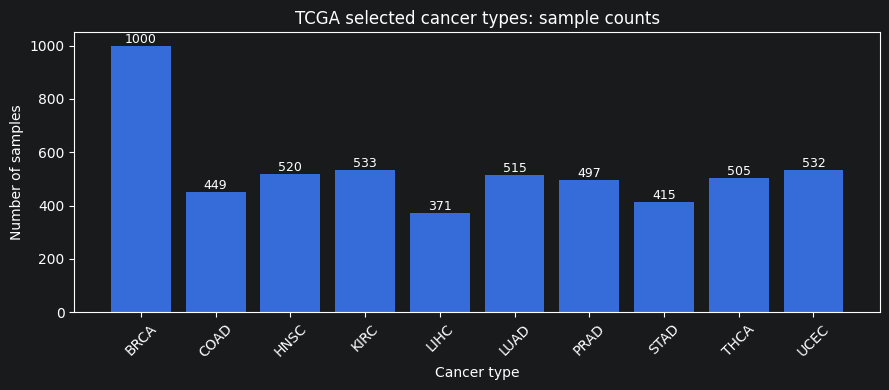

[figure] saved: /Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/figures/expression_distribution.png


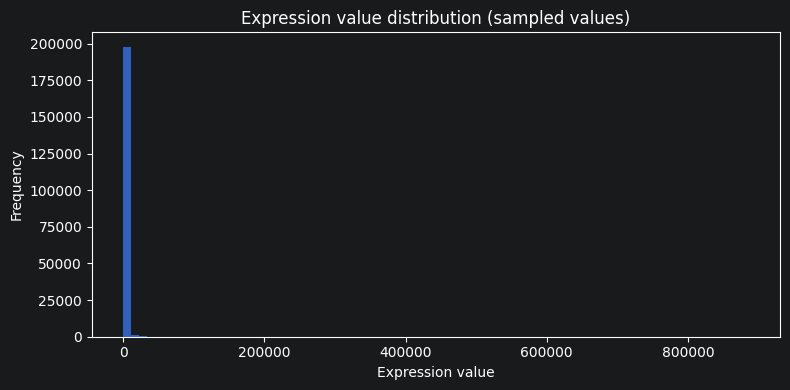

(<Figure size 800x400 with 1 Axes>,
 <Axes: title={'center': 'Expression value distribution (sampled values)'}, xlabel='Expression value', ylabel='Frequency'>)

In [20]:
plot_class_counts(
    y,
    title="TCGA selected cancer types: sample counts",
    save_path=cfg.figure_dir / "class_counts.png",
)

plot_expression_distribution(
    X,
    title="Expression value distribution (sampled values)",
    save_path=cfg.figure_dir / "expression_distribution.png",
)

## 6. 모델링 전 차원축소 시각화

고차원 gene expression 데이터를 바로 이해하기 어렵기 때문에 PCA와 t-SNE/UMAP으로 2차원에 투영한다.  
이 단계는 **정답을 맞히는 모델링 전**, 데이터 자체에 암종 구분 신호가 있는지 확인하는 EDA이다.

PCA, t-SNE, UMAP은 NaN을 직접 처리하지 못하므로, EDA용 matrix에서는 다음 처리를 먼저 수행한다.

1. 결측 비율이 너무 높은 gene 제거
2. 남은 작은 결측치는 gene별 median으로 대치
3. 분산이 큰 gene 선택
4. StandardScaler 적용

실제 모델 학습용 전처리는 뒤에서 train/test split 이후 train set에만 fit한다.


,item,value
0,eda_input_genes,20501
1,eda_genes_after_missing_filter,20501
2,eda_selected_top_variable_genes,3000
3,eda_remaining_missing_values,0


PCA explained variance ratio: [0.09257691 0.06612327]
[figure] saved: /Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/figures/eda_pca_raw_expression.png


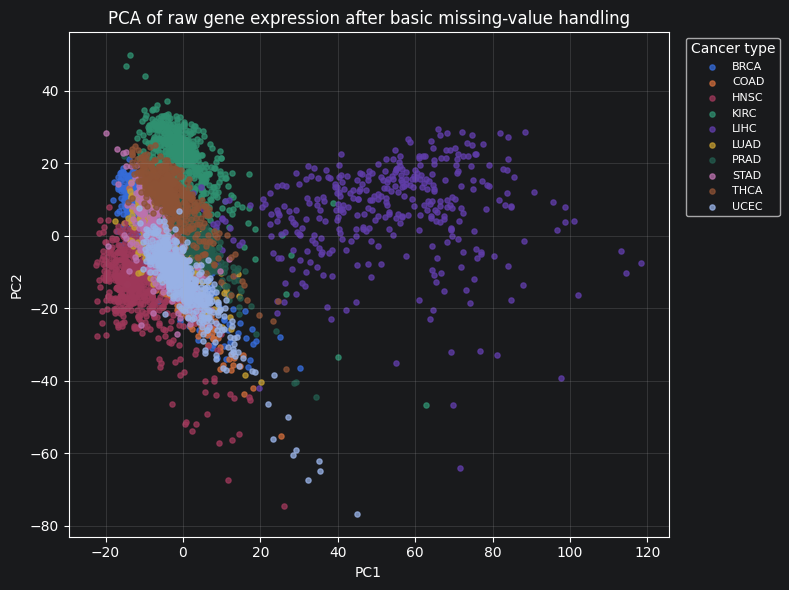

(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': 'PCA of raw gene expression after basic missing-value handling'}, xlabel='PC1', ylabel='PC2'>)

In [21]:
# EDA용 matrix 생성: 결측치 처리 + top variable gene 선택 + scaling
# 이 처리는 시각화용이며, 실제 모델 학습용 전처리는 뒤에서 train set 기준으로 다시 수행한다.
X_eda_scaled, eda_genes, eda_report = prepare_eda_matrix(
    X,
    top_n_genes=cfg.top_n_genes,
    max_missing_fraction=0.2,
    random_state=cfg.random_state,
)

display(eda_report)

pca_emb, pca_model = compute_pca(X_eda_scaled, n_components=2, random_state=cfg.random_state)
print("PCA explained variance ratio:", pca_model.explained_variance_ratio_)

plot_embedding(
    pca_emb,
    y,
    title="PCA of raw gene expression after basic missing-value handling",
    xlabel="PC1",
    ylabel="PC2",
    save_path=cfg.figure_dir / "eda_pca_raw_expression.png",
)


[figure] saved: /Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/figures/eda_umap_raw_expression.png


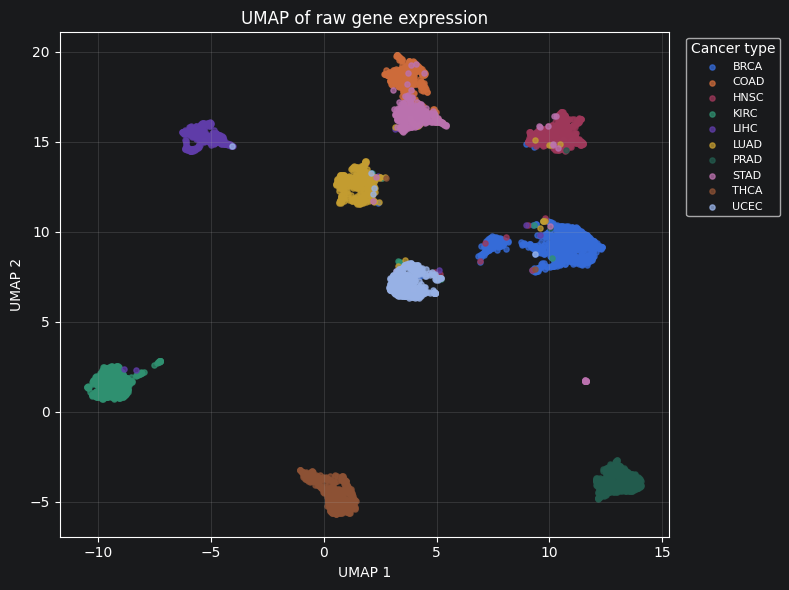

(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': 'UMAP of raw gene expression'}, xlabel='UMAP 1', ylabel='UMAP 2'>)

In [22]:
# t-SNE 또는 UMAP 시각화. UMAP 미설치 시 자동으로 t-SNE를 사용한다.
nonlinear_emb, nonlinear_name = compute_embedding(
    X_eda_scaled,
    method=cfg.embedding_method,
    random_state=cfg.random_state,
)

plot_embedding(
    nonlinear_emb,
    y,
    title=f"{nonlinear_name} of raw gene expression",
    xlabel=f"{nonlinear_name} 1",
    ylabel=f"{nonlinear_name} 2",
    save_path=cfg.figure_dir / f"eda_{nonlinear_name.lower().replace('-', '')}_raw_expression.png",
)

## 7. 전처리: train/test split, imputation, feature selection, scaling

데이터 누수(data leakage)를 막기 위해 아래 원칙을 지켰다.

1. 먼저 train/test split을 수행한다.
2. 결측 비율이 높은 gene 제거 기준은 train set에서만 계산한다.
3. median imputer는 train set에만 fit한다.
4. top variable gene selection은 train set에만 fit한다.
5. StandardScaler도 train set에만 fit하고 test set에는 transform만 적용한다.


In [23]:
prepared = prepare_model_data(
    X,
    y,
    top_n_genes=cfg.top_n_genes,
    test_size=cfg.test_size,
    random_state=cfg.random_state,
    max_missing_fraction=0.2,
)

print("Train shape:", prepared.X_train.shape)
print("Test shape:", prepared.X_test.shape)
print("Number of selected genes:", len(prepared.feature_names))
print("Classes:", prepared.class_names)

cleaning_report_df = pd.DataFrame(
    [{"item": key, "value": value} for key, value in prepared.cleaning_report.items()]
)
print_section("Leakage-safe preprocessing report")
display(cleaning_report_df)
save_table(cleaning_report_df, cfg.table_dir / "preprocessing_report.csv")


Train shape: (4269, 3000)
Test shape: (1068, 3000)
Number of selected genes: 3000
Classes: ['BRCA', 'COAD', 'HNSC', 'KIRC', 'LIHC', 'LUAD', 'PRAD', 'STAD', 'THCA', 'UCEC']

  Leakage-safe preprocessing report


,item,value
0,original_genes,2.050100e+04
1,original_missing_values,2.300575e+06
2,original_missing_fraction,2.102636e-02
3,genes_after_missing_variance_filter,2.026500e+04
4,selected_top_variable_genes,3.000000e+03
5,train_remaining_missing_values,0.000000e+00
6,test_remaining_missing_values,0.000000e+00


PosixPath('/Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/tables/preprocessing_report.csv')

## 8. Classical ML 모델 학습

다음 4가지 모델 학습시켜서 모델을 비교

- Dummy majority baseline
- Logistic Regression with L2 Regularization(L2패널티 사용)
- Logistic Regression with L1 Regularization(L1패널티 사용)
- Random Forest

Logistic Regression은 해석 가능한 coefficient를 제공하고, Random Forest는 nonlinear baseline과 feature importance를 제공한다.

[fit] Dummy_majority
[fit] LogReg_L2
[fit] LogReg_L1
[fit] RandomForest

  Classical model performance


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,roc_auc_ovr_macro
0,RandomForest,0.991573,0.992349,0.993292,0.992349,0.992802,0.999864
1,LogReg_L2,0.992509,0.992986,0.992379,0.992986,0.992636,0.999952
2,LogReg_L1,0.990637,0.991255,0.990595,0.991255,0.990895,0.999920
3,Dummy_majority,0.187266,0.100000,0.018727,0.100000,0.031546,0.500000


[figure] saved: /Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/figures/classical_model_macro_f1.png


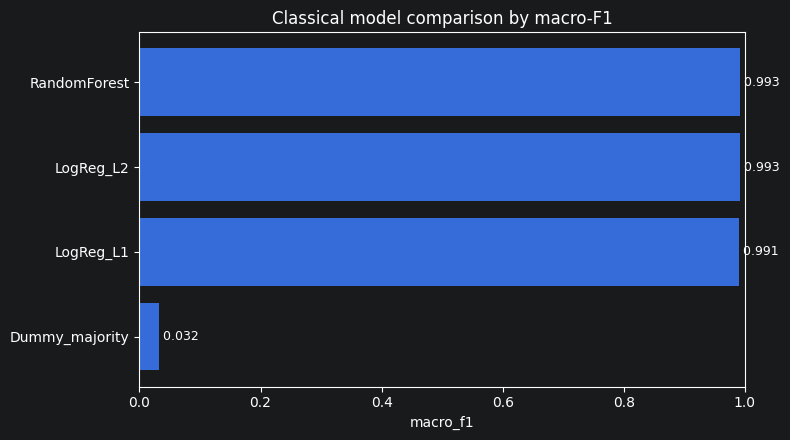

(<Figure size 800x450 with 1 Axes>,
 <Axes: title={'center': 'Classical model comparison by macro-F1'}, xlabel='macro_f1'>)

In [24]:
models = build_classical_models(
    random_state=cfg.random_state,
    run_l1=cfg.run_l1_logreg,
    run_random_forest=cfg.run_random_forest,
)

fitted_models = fit_classical_models(models, prepared.X_train, prepared.y_train)
metrics_df, predictions, probabilities = evaluate_models(fitted_models, prepared.X_test, prepared.y_test)

print_section("Classical model performance")
display(metrics_df)
save_table(metrics_df, cfg.table_dir / "classical_model_metrics.csv")

plot_metrics_table(
    metrics_df,
    metric="macro_f1",
    title="Classical model comparison by macro-F1",
    save_path=cfg.figure_dir / "classical_model_macro_f1.png",
)

## 9. Confusion Matrix와 class별 성능 해석

어떤 암종이 잘 맞고 어떤 암종이 헷갈리는지 확인한다.

Best classical model: RandomForest


,BRCA,COAD,HNSC,KIRC,LIHC,LUAD,PRAD,STAD,THCA,UCEC
BRCA,197,0,3,0,0,0,0,0,0,0
COAD,0,90,0,0,0,0,0,0,0,0
HNSC,2,0,102,0,0,0,0,0,0,0
KIRC,1,0,0,106,0,0,0,0,0,0
LIHC,0,0,0,1,73,0,0,0,0,0
LUAD,1,0,0,0,0,101,0,0,0,1
PRAD,0,0,0,0,0,0,99,0,0,0
STAD,0,0,0,0,0,0,0,83,0,0
THCA,0,0,0,0,0,0,0,0,101,0
UCEC,0,0,0,0,0,0,0,0,0,107


[figure] saved: /Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/figures/confusion_matrix_RandomForest.png


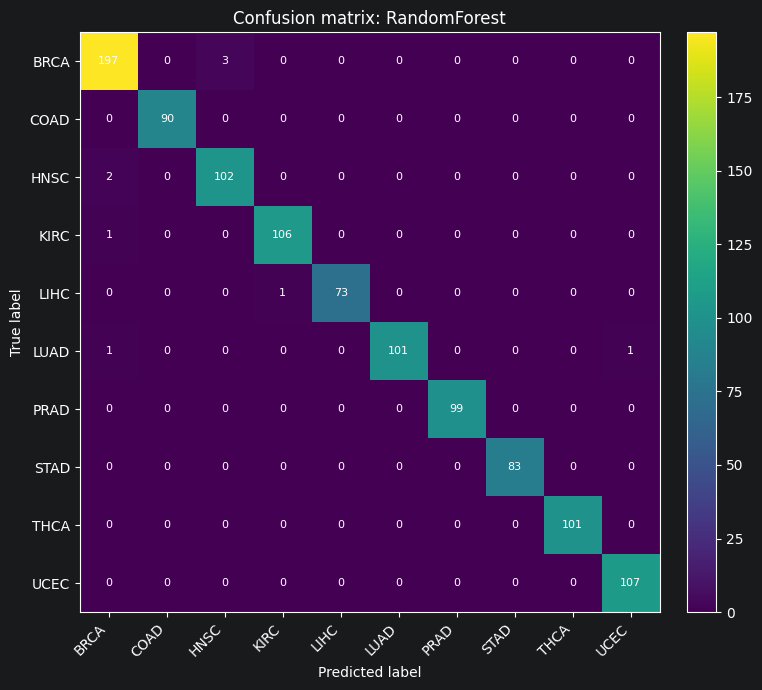

,class,precision,recall,f1-score,support
0,BRCA,0.980100,0.985000,0.982544,200.000000
1,COAD,1.000000,1.000000,1.000000,90.000000
2,HNSC,0.971429,0.980769,0.976077,104.000000
3,KIRC,0.990654,0.990654,0.990654,107.000000
4,LIHC,1.000000,0.986486,0.993197,74.000000
5,LUAD,1.000000,0.980583,0.990196,103.000000
6,PRAD,1.000000,1.000000,1.000000,99.000000
7,STAD,1.000000,1.000000,1.000000,83.000000
8,THCA,1.000000,1.000000,1.000000,101.000000
9,UCEC,0.990741,1.000000,0.995349,107.000000


PosixPath('/Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/tables/classification_report_RandomForest.csv')

In [25]:
best_classical_name = get_best_model_name(metrics_df, metric="macro_f1")
best_classical_pred = predictions[best_classical_name]
print("Best classical model:", best_classical_name)

cm_df = confusion_matrix_df(
    prepared.y_test,
    best_classical_pred,
    class_names=prepared.class_names,
    normalize=None,
)
display(cm_df)

plot_confusion_matrix(
    cm_df,
    title=f"Confusion matrix: {best_classical_name}",
    save_path=cfg.figure_dir / f"confusion_matrix_{best_classical_name}.png",
)

report_df = classification_report_df(prepared.y_test, best_classical_pred, prepared.class_names)
display(report_df)
save_table(report_df, cfg.table_dir / f"classification_report_{best_classical_name}.csv")

## 10. 해석 가능한 candidate marker gene 정리

분류 모델이 암종 구분에 중요하게 사용한 candidate gene을 정리

In [26]:
interpretation_tables = []

if "LogReg_L2" in fitted_models:
    logreg_l2_top = logistic_top_genes(
        fitted_models["LogReg_L2"],
        feature_names=prepared.feature_names,
        class_names=prepared.class_names,
        top_n=15,
    )
    print_section("Top genes from L2 Logistic Regression coefficients")
    display(logreg_l2_top.head(30))
    save_table(logreg_l2_top, cfg.table_dir / "top_genes_logreg_l2.csv")
    interpretation_tables.append(logreg_l2_top)

if "LogReg_L1" in fitted_models:
    l1_nonzero = logistic_nonzero_genes(
        fitted_models["LogReg_L1"],
        feature_names=prepared.feature_names,
    )
    print_section("Non-zero genes from L1 Logistic Regression")
    print("Number of non-zero genes:", len(l1_nonzero))
    display(l1_nonzero.head(30))
    save_table(l1_nonzero, cfg.table_dir / "nonzero_genes_logreg_l1.csv")
    interpretation_tables.append(l1_nonzero.head(100))

if "RandomForest" in fitted_models:
    rf_top = random_forest_top_genes(
        fitted_models["RandomForest"],
        feature_names=prepared.feature_names,
        top_n=30,
    )
    print_section("Top genes from Random Forest feature importance")
    display(rf_top.head(30))
    save_table(rf_top, cfg.table_dir / "top_genes_random_forest.csv")
    interpretation_tables.append(rf_top)

if interpretation_tables:
    overlap_df = overlapping_top_genes(*interpretation_tables)
    print_section("Genes repeatedly selected by multiple interpretation methods")
    display(overlap_df.head(30))
    save_table(overlap_df, cfg.table_dir / "overlapping_top_genes.csv")


  Top genes from L2 Logistic Regression coefficients


,class,rank,gene,coef,class_direction_score,abs_coef
0,BRCA,1,SFRP1,0.099437,0.099437,0.099437
1,BRCA,2,GABRP,0.094445,0.094445,0.094445
2,BRCA,3,POSTN,0.083503,0.083503,0.083503
3,BRCA,4,PADI2,0.081201,0.081201,0.081201
4,BRCA,5,MGP,0.077879,0.077879,0.077879
5,BRCA,6,CALML5,0.076296,0.076296,0.076296
6,BRCA,7,TCN1,0.073034,0.073034,0.073034
7,BRCA,8,SLC5A6,0.067079,0.067079,0.067079
8,BRCA,9,TRPS1,0.065797,0.065797,0.065797
9,BRCA,10,CRABP2,0.064756,0.064756,0.064756



  Non-zero genes from L1 Logistic Regression
Number of non-zero genes: 869


,gene,max_abs_coef
0,HOXB13,1.517149
1,SOX17,1.436419
2,TRPS1,1.333638
3,GATA3,1.257542
4,RPL12,1.229855
5,NKX3-1,1.063590
6,TP63,1.046526
7,HMGB3,1.017436
8,NAPSA,1.007447
9,GALNT14,0.969562



  Top genes from Random Forest feature importance


,rank,gene,importance
0,1,PAX8,0.013048
1,2,SOX17,0.011671
2,3,TG,0.010642
3,4,SLC17A3,0.008393
4,5,TSHR,0.008055
5,6,SFTA3,0.007493
6,7,KLK3,0.006917
7,8,NKX2-1,0.006816
8,9,KLK2,0.006782
9,10,FOXE1,0.006591



  Genes repeatedly selected by multiple interpretation methods


,gene,n_tables
0,EFHD1,3
1,FOXE1,3
2,HOXB13,3
3,KLK2,3
4,LGALS4,3
5,NKX3-1,3
6,PRSS3,3
7,SOX17,3
8,TSHR,3
9,AGT,2


[figure] saved: /Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/figures/top_genes_logreg_BRCA.png


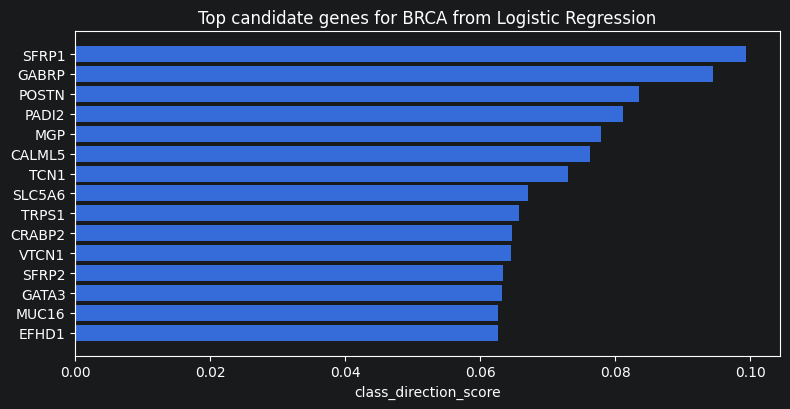

In [27]:
# 예시: 첫 번째 암종에 대한 Logistic Regression top genes 시각화
if "LogReg_L2" in fitted_models:
    example_class = prepared.class_names[0]
    plot_df = logreg_l2_top[logreg_l2_top["class"] == example_class].copy()
    plot_top_genes(
        plot_df,
        score_col="class_direction_score",
        title=f"Top candidate genes for {example_class} from Logistic Regression",
        top_n=15,
        save_path=cfg.figure_dir / f"top_genes_logreg_{example_class}.png",
    )

## 11. MLP 모델 학습

MLP 구조를 확장해 TCGA 데이터에 적용한다.
여기서 MLP는 단순히 성능 비교용일 뿐 아니라, hidden layer의 latent representation을 추출하기 위한 모델이다.


  Training MLP
Epoch 001 | train_loss=0.2588 | val_loss=0.0852 | val_acc=0.977
Epoch 010 | train_loss=0.0128 | val_loss=0.1024 | val_acc=0.980
Epoch 020 | train_loss=0.0000 | val_loss=0.1009 | val_acc=0.983
Epoch 030 | train_loss=0.0000 | val_loss=0.1051 | val_acc=0.981
[early stopping] No validation loss improvement for 15 epochs.


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,roc_auc_ovr_macro
0,MLP,0.991573,0.992025,0.991468,0.992025,0.991692,0.999634


[figure] saved: /Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/figures/mlp_training_history.png


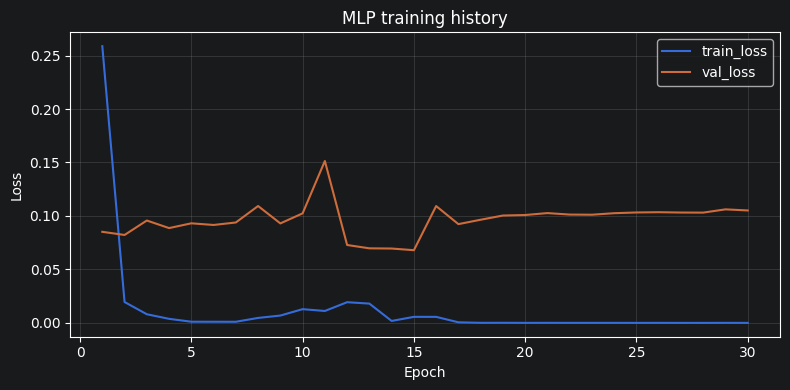

[figure] saved: /Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/figures/confusion_matrix_mlp.png


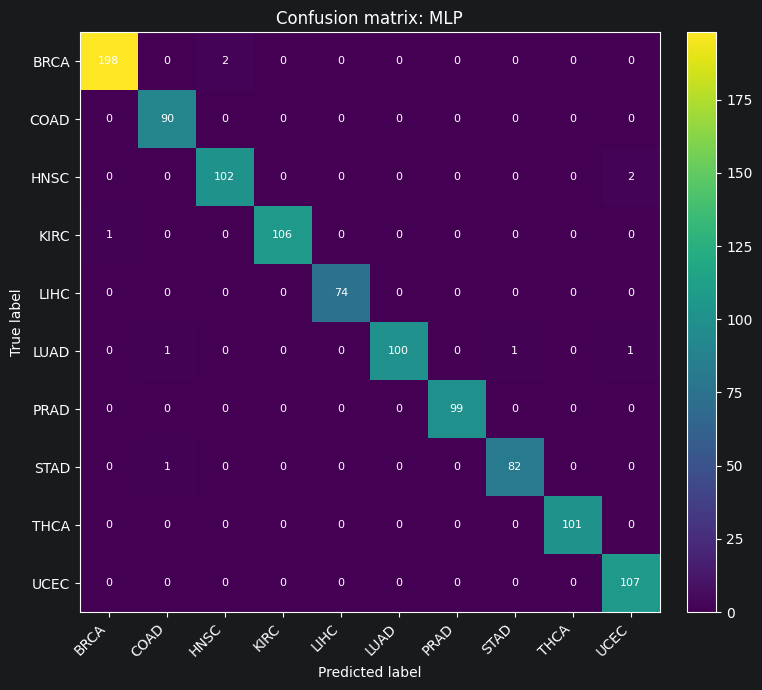

In [28]:
mlp_result = None
mlp_metrics_df = pd.DataFrame()
latent_all = None

if cfg.run_mlp and torch_available():
    print_section("Training MLP")
    mlp_result = train_mlp_classifier(
        prepared.X_train,
        prepared.y_train,
        prepared.X_test,
        prepared.y_test,
        n_classes=len(prepared.class_names),
        hidden_dim=256,
        latent_dim=64,
        dropout=0.25,
        epochs=cfg.mlp_epochs,
        batch_size=cfg.mlp_batch_size,
        learning_rate=cfg.mlp_learning_rate,
        patience=cfg.mlp_patience,
        random_state=cfg.random_state,
        verbose=True,
    )
    mlp_metrics_df = pd.DataFrame([{ "model": "MLP", **mlp_result.metrics }])
    display(mlp_metrics_df)
    save_table(mlp_metrics_df, cfg.table_dir / "mlp_metrics.csv")

    plot_training_history(
        mlp_result.history,
        save_path=cfg.figure_dir / "mlp_training_history.png",
    )

    mlp_cm_df = confusion_matrix_df(
        prepared.y_test,
        mlp_result.y_pred,
        class_names=prepared.class_names,
        normalize=None,
    )
    plot_confusion_matrix(
        mlp_cm_df,
        title="Confusion matrix: MLP",
        save_path=cfg.figure_dir / "confusion_matrix_mlp.png",
    )

    latent_all = encode_mlp_latent(
        mlp_result.model,
        prepared.X_all_scaled,
        device=mlp_result.device,
    )
else:
    print("MLP skipped. cfg.run_mlp is False or PyTorch is not installed.")

## 12. 전체 모델 성능 비교

Classical ML과 MLP 결과를 하나의 표로 합친다.

,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,roc_auc_ovr_macro
0,RandomForest,0.991573,0.992349,0.993292,0.992349,0.992802,0.999864
1,LogReg_L2,0.992509,0.992986,0.992379,0.992986,0.992636,0.999952
2,MLP,0.991573,0.992025,0.991468,0.992025,0.991692,0.999634
3,LogReg_L1,0.990637,0.991255,0.990595,0.991255,0.990895,0.999920
4,Dummy_majority,0.187266,0.100000,0.018727,0.100000,0.031546,0.500000


[figure] saved: /Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/figures/all_model_macro_f1.png


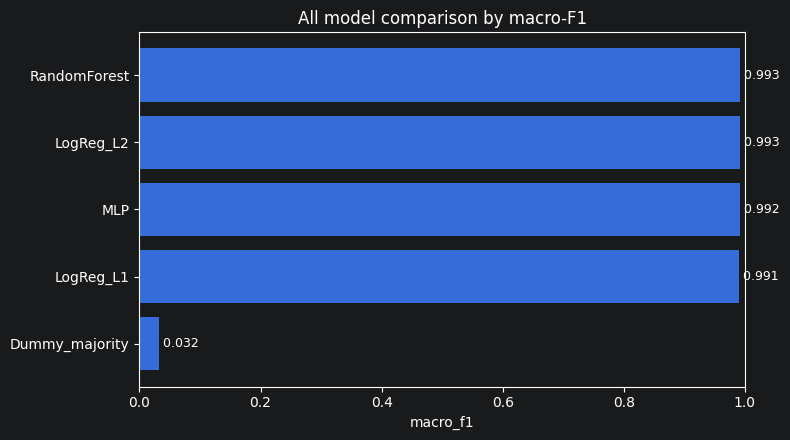

(<Figure size 800x450 with 1 Axes>,
 <Axes: title={'center': 'All model comparison by macro-F1'}, xlabel='macro_f1'>)

In [29]:
all_metrics_df = pd.concat([metrics_df, mlp_metrics_df], ignore_index=True)
all_metrics_df = all_metrics_df.sort_values("macro_f1", ascending=False).reset_index(drop=True)

display(all_metrics_df)
save_table(all_metrics_df, cfg.table_dir / "all_model_metrics.csv")

plot_metrics_table(
    all_metrics_df,
    metric="macro_f1",
    title="All model comparison by macro-F1",
    save_path=cfg.figure_dir / "all_model_macro_f1.png",
)

## 13. MLP latent representation 분석

원본 expression feature space와 MLP hidden layer representation을 비교한다.  
발표에서는 이 그림을 통해 “모델이 암종별 구조를 어떻게 학습했는지”를 직관적으로 보여줄 수 있다.

[figure] saved: /Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/figures/model_input_pca.png


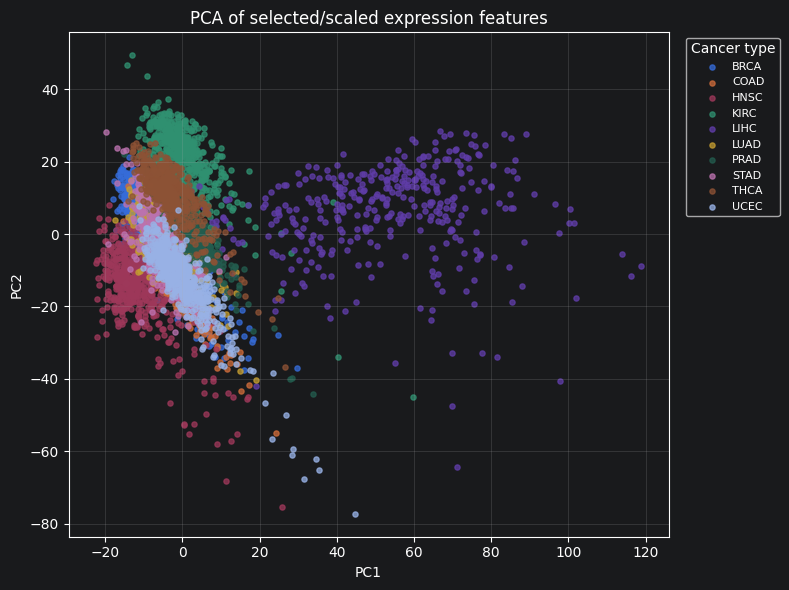

[figure] saved: /Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/figures/mlp_latent_pca.png


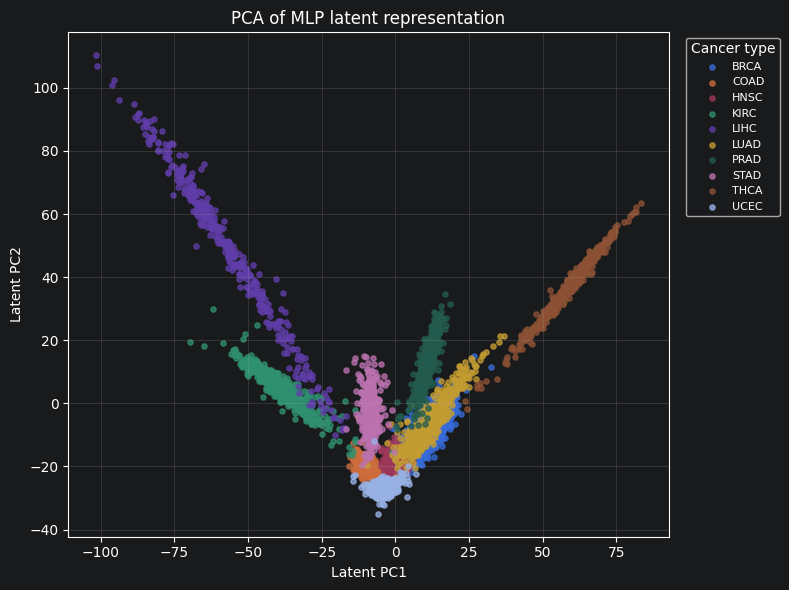

[figure] saved: /Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/figures/mlp_latent_umap.png


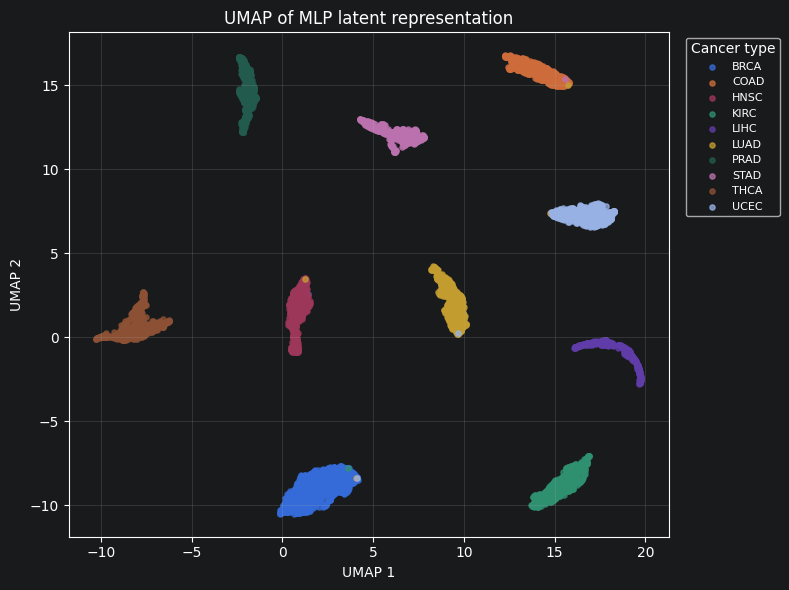

In [30]:
# Raw selected expression PCA
raw_pca_emb, raw_pca_model = compute_pca(prepared.X_all_scaled, n_components=2, random_state=cfg.random_state)
plot_embedding(
    raw_pca_emb,
    prepared.y_all_labels,
    title="PCA of selected/scaled expression features",
    xlabel="PC1",
    ylabel="PC2",
    save_path=cfg.figure_dir / "model_input_pca.png",
)

# MLP latent PCA and nonlinear embedding
if latent_all is not None:
    latent_pca_emb, latent_pca_model = compute_pca(latent_all, n_components=2, random_state=cfg.random_state)
    plot_embedding(
        latent_pca_emb,
        prepared.y_all_labels,
        title="PCA of MLP latent representation",
        xlabel="Latent PC1",
        ylabel="Latent PC2",
        save_path=cfg.figure_dir / "mlp_latent_pca.png",
    )

    latent_nonlin_emb, latent_nonlin_name = compute_embedding(
        latent_all,
        method=cfg.embedding_method,
        random_state=cfg.random_state,
    )
    plot_embedding(
        latent_nonlin_emb,
        prepared.y_all_labels,
        title=f"{latent_nonlin_name} of MLP latent representation",
        xlabel=f"{latent_nonlin_name} 1",
        ylabel=f"{latent_nonlin_name} 2",
        save_path=cfg.figure_dir / f"mlp_latent_{latent_nonlin_name.lower().replace('-', '')}.png",
    )
else:
    print("No MLP latent representation available.")

## 14. Clustering 보조 분석

정답 label 없이 K-means clustering을 했을 때 암종 구조가 얼마나 나타나는지 확인한다.  
여기서는 ARI, NMI, silhouette score를 사용한다.

In [31]:
spaces = {}
raw_pca20, _ = compute_pca(
    prepared.X_all_scaled,
    n_components=min(20, prepared.X_all_scaled.shape[1], prepared.X_all_scaled.shape[0] - 1),
    random_state=cfg.random_state,
)
spaces["Expression PCA(20)"] = raw_pca20

if latent_all is not None:
    spaces["MLP latent"] = latent_all

cluster_df = compare_kmeans_spaces(
    spaces,
    y_true=prepared.y_all,
    n_clusters=len(prepared.class_names),
    random_state=cfg.random_state,
)

display(cluster_df)
save_table(cluster_df, cfg.table_dir / "clustering_comparison.csv")

,space,ARI,NMI,silhouette
0,Expression PCA(20),0.705875,0.789432,0.307137
1,MLP latent,0.975219,0.970961,0.630329


PosixPath('/Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/tables/clustering_comparison.csv')

## 15. 결과 요약 및 발표용 메시지

아래 셀은 보고서/발표에 바로 옮길 수 있는 핵심 산출물을 정리한다.

In [32]:
print_section("Final summary")

best_overall = all_metrics_df.iloc[0]
print(f"Best model: {best_overall['model']}")
print(f"Accuracy: {best_overall['accuracy']:.3f}")
print(f"Balanced accuracy: {best_overall['balanced_accuracy']:.3f}")
print(f"Macro-F1: {best_overall['macro_f1']:.3f}")

print("\nSaved figures:")
for p in sorted(cfg.figure_dir.glob("*.png")):
    print("-", p)

print("\nSaved tables:")
for p in sorted(cfg.table_dir.glob("*.csv")):
    print("-", p)


  Final summary
Best model: RandomForest
Accuracy: 0.992
Balanced accuracy: 0.992
Macro-F1: 0.993

Saved figures:
- /Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/figures/all_model_macro_f1.png
- /Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/figures/class_counts.png
- /Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/figures/classical_model_macro_f1.png
- /Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/figures/confusion_matrix_RandomForest.png
- /Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/figures/confusion_matrix_mlp.png
- /Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/figures/eda_pca_raw_expression.png
- /Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/figures/eda_tsne_raw_expression.png
- /Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/figures/eda_umap_raw_expression.png
- /Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/figures/expression_distribution.png
- /Users/martin/Git/DS-ML/tcga_pancancer_project/outputs/figu

## 16. 최종 결과 보고서 대충 정리

- TCGA Pan-Cancer RNA-seq 데이터는 암종별 gene expression pattern을 충분히 포함하고 있어 multi-class classification에 적합했다.
- Logistic Regression은 coefficient를 통해 class-specific candidate gene을 해석하기 쉽다는 장점이 있다.
- Random Forest는 nonlinear model로서 비교 기준이 되며, feature importance를 통해 추가적인 gene ranking을 제공한다.
- MLP는 hidden layer latent representation을 통해 암종별 발현 구조를 시각화하는 데 유용하다.
- 한계점은 다음과 같다.
  - 외부 검증 cohort를 사용하지 않았다.
  - batch effect를 깊게 보정하지 않았다.
  - candidate marker gene은 모델 기반 ranking이며, 생물학적 검증이 필요하다.
  - 실제 임상 진단 모델이 아니라 공개 데이터를 이용한 데이터 과학 프로세스 실습이다.